# AOCR — PoP Clustering with Capacitated p-Median

This notebook addresses the **Point-of-Presence (PoP) location problem**, modeled as a **capacitated p-median problem**, a special case of *location problems*.

Within the location-problem setting, the objective is to determine the locations of *service centers* (PoPs) chosen from a finite set of candidates (*discrete model*), to satisfy geographically dispersed demand (users), minimizing **assignment costs** (latency + economic transport cost) under **capacity constraints**.

The **p-median** problem is obtained when location costs are homogeneous and the number of centers to open is fixed to $p$: the objective function reduces to minimizing only the sum of assignment costs. Adding capacity constraints on service centers leads to the **capacitated plant location** variant, where each center can serve only sets of customers whose total demand does not exceed its capacity.

**Implemented methods**:
1. **MILP** — exact Mixed-Integer Linear Programming formulation solved with PuLP / CBC;
2. **Greedy-add** — constructive *greedy* heuristic with capacitated assignment;
3. **Local Search (Teitz & Bart)** — improvement heuristic with a 1-swap neighborhood (*vertex substitution*), adapted to the capacity constraint;
4. **Tabu Search** — metaheuristic with tabu list and aspiration criterion;
5. **Simulated Annealing** — metaheuristic with probabilistic acceptance and cooling schedule;
6. **k-Means** — baseline with continuous centroids (*imaginary* centroids, not constrained to real candidates).


## 1 • Imports and dependencies


In [1]:
import json
import math
import time
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from tqdm.auto import tqdm

# Global seaborn style
sns.set_theme(style="whitegrid", context="notebook", palette="Set2")

# k-Means baseline
from sklearn.cluster import KMeans

# MILP solver 
import pulp

## 2 • Configuration and data loading

Experimental parameters are centralized in the `CONFIG` dictionary, so the whole campaign can be repeated in a controlled and comparable way.

Input data are loaded from the `data/` folder:

- `user_anchors.json`: anchor cities used to generate demand nodes;
- `pop_candidates.json`: discrete set of candidate PoPs;
- `generated/` and `index.json`: cache/registry of generated user instances.

The configuration used in this notebook is:

- `n_users = [120, 300, 600, 1000]`
- `p_values = [3, 5, 8, 10, 13, 15, 18, 20]`
- `seeds = [0, 1, 2]`
- `latency_per_km_ms = 0.02`, `cost_per_km_eur = 0.03`
- `objective_weights = {'latency': 1.0, 'cost': 1.0}`
- `capacity.multiplier = 1.3`, `capacity.heterogeneity_factor = 0.2`
- `kmeans.max_iter = 50`, `kmeans.n_init = 3`
- `cbc.time_limit_s = 120`

The effective unit cost (used to build the cost matrix) is:

$$c_{\mathrm{eff}} = w_{\mathrm{lat}}\,\ell_{\mathrm{km}} + w_{\mathrm{cost}}\,\kappa_{\mathrm{km}}$$

with:

- $\ell_{\mathrm{km}}$ = latency component per km (variable `latency_per_km_ms`);
- $\kappa_{\mathrm{km}}$ = economic cost component per km (variable `cost_per_km_eur`).

The base capacity per center is computed as:

$$Q_{\mathrm{base}} = \text{multiplier} \cdot \frac{\sum_{j\in J} d_j}{p}$$

with heterogeneity controlled by `heterogeneity_factor`.

Operational interpretation of `capacity.multiplier = 1.3`: on average, each PoP can serve about **30% more** than the uniform share $\frac{\sum_j d_j}{p}$ of total demand.


In [2]:
# ── Experimental parameters ─────────────────────────────────────────
CONFIG = {
    'n_users': [120, 300, 600, 1000],          # instance sizes (demand nodes)
    'p_values': [3, 5, 8, 10, 13, 15, 18, 20], # number of service centers to open
    'seeds': [0, 1, 2],                        # seed for reproducibility
    'latency_per_km_ms': 0.02,                 # latency component of assignment cost
    'cost_per_km_eur': 0.03,                   # economic component of assignment cost
    'objective_weights': {                     # weights in the objective function
        'latency': 1.0,
        'cost': 1.0,
    },
    'capacity': {                              # capacity constraints on service centers
        'multiplier': 1.3,                     # slack over average demand
        'heterogeneity_factor': 0.2,           # maximum heterogeneous percentage variation
    },
    'kmeans': {                                # k-Means baseline parameters
        'max_iter': 50,
        'n_init': 3,
    },
    'cbc': {                                   # CBC solver parameters (MILP)
        'time_limit_s': 120,                   # time limit per solve
    },
    'cache': {                                 # results caching
        'use_cache': True,                      # use CSV if available
        'force_recompute': False,               # ignore cache and recompute
        'dir': 'results/cache',                 # cache directory
    },
}

# ── Input data loading ─────────────────────────────────────────────
# I = set of candidate sites for service centers (PoPs)
# J = set of demand nodes (users, anchor cities)
user_anchors_path = Path('data/user_anchors.json')
pop_candidates_path = Path('data/pop_candidates.json')

with user_anchors_path.open('r', encoding='utf-8') as f:
    USER_ANCHORS = json.load(f)

with pop_candidates_path.open('r', encoding='utf-8') as f:
    POP_CANDIDATES = json.load(f)

# Jitter radius for demand-node generation (km) and demand range d_j
USER_JITTER_KM = 120.0
DEMAND_MIN = 1.0
DEMAND_MAX = 5.0

# Candidate service center coordinates as a NumPy array
pop_coords = np.array([[c['lat'], c['lon']] for c in POP_CANDIDATES], dtype=float)
print(f"Loaded candidate service centers (PoPs): {len(pop_coords)}")

Loaded candidate service centers (PoPs): 20


Generated user instances are automatically saved in `data/generated/` and reused when already available, ensuring **reproducibility** of the experiments. In addition, the `data/index.json` file acts as a **dataset registry**: it tracks every generated instance.


## 3 • Utility functions

Functions shared across the different solution methods:

- **`haversine_matrix`** — geodesic-distance matrix between users and candidate PoPs.
  In location problems, distance is a central component of assignment cost. In theory, metrics from the Minkowski family are often used:

  $$d_k(P_i,P_j)=\left(|x_i-x_j|^k + |y_i-y_j|^k\right)^{1/k}$$

  with $k=1$ (linear/Manhattan metric) and $k=2$ (Euclidean metric). Here, since we use geographic coordinates (latitude/longitude), we instead use the **Haversine** formula on a spherical surface.

  $$a = \sin^2\!\left(\frac{\Delta\varphi}{2}\right) + \cos(\varphi_1)\cos(\varphi_2)\sin^2\!\left(\frac{\Delta\lambda}{2}\right)$$
  $$d = 2R\,\arcsin\!\left(\sqrt{a}\right)$$

  where $\varphi$ is latitude, $\lambda$ is longitude, $R \approx 6371\,\text{km}$, and $d$ is the distance between the two points.

- **`sample_users`** — generation / loading of user instances (demand nodes $j \in J$).
- **`build_capacities`** — computation of capacities $m_i$ for each candidate PoP (service centers $i \in I$).
- **`effective_cost_per_km`** — **assignment cost** per km, weighted combination of latency and economic transport cost.


In [3]:
EARTH_RADIUS_KM = 6371.0


def haversine_matrix(coords_a: np.ndarray, coords_b: np.ndarray) -> np.ndarray:
    """Geodesic distance matrix (Haversine) between two point sets.

    Args:
        coords_a: Array (n, 2) with [lat, lon] columns in degrees — demand nodes.
        coords_b: Array (m, 2) with [lat, lon] columns in degrees — candidate centers.

    Returns:
        (n, m) distance matrix in kilometers.
    """
    lat1 = np.deg2rad(coords_a[:, 0])[:, None]
    lon1 = np.deg2rad(coords_a[:, 1])[:, None]
    lat2 = np.deg2rad(coords_b[:, 0])[None, :]
    lon2 = np.deg2rad(coords_b[:, 1])[None, :]

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c


def sample_users(n_users: int, seed: int, generated_dir: Path = Path('data/generated')):
    """Loads a demand-node instance or generates a new one if it does not already exist.

    Each user is placed with random jitter around an anchor city
    chosen uniformly. Demand d_j is sampled from U(DEMAND_MIN, DEMAND_MAX).
    Generated datasets are saved in `generated_dir` and registered in
    `data/index.json`.

    Args:
        n_users: Number of demand nodes to generate.
        seed: Seed for the random generator.
        generated_dir: Destination folder.

    Returns:
        Tuple (coords, demands) with coordinates (n, 2) and demands d_j (n,).
    """
    generated_dir.mkdir(parents=True, exist_ok=True)
    path = generated_dir / f"users_n{n_users}_seed{seed}.json"

    # If the file already exists, reload it directly
    if path.exists():
        data = json.loads(path.read_text(encoding='utf-8'))
        coords = np.array([[d['lat'], d['lon']] for d in data], dtype=float)
        demands = np.array([d['demand'] for d in data], dtype=float)
        return coords, demands

    # Generate a new demand-node instance
    rng = np.random.default_rng(seed)
    anchor_idx = rng.integers(0, len(USER_ANCHORS), size=n_users)
    coords = np.zeros((n_users, 2), dtype=float)

    for i, idx in enumerate(anchor_idx):
        base = USER_ANCHORS[int(idx)]
        r = USER_JITTER_KM * np.sqrt(rng.random())
        theta = 2 * np.pi * rng.random()
        dlat = (r * np.cos(theta)) / 111.0
        lat_rad = math.radians(base['lat'])
        dlon = (r * np.sin(theta)) / (111.0 * math.cos(lat_rad))
        coords[i, 0] = base['lat'] + dlat
        coords[i, 1] = base['lon'] + dlon

    demands = rng.uniform(DEMAND_MIN, DEMAND_MAX, size=n_users)

    # Save to disk
    data = [
        {"lat": float(coords[i, 0]), "lon": float(coords[i, 1]), "demand": float(demands[i])}
        for i in range(n_users)
    ]
    path.write_text(json.dumps(data, indent=2), encoding='utf-8')

    # Update dataset registry
    index_path = Path('data/index.json')
    index_data = json.loads(index_path.read_text(encoding='utf-8'))

    record = {
        'file': str(path.as_posix()),
        'n_users': n_users,
        'seed': seed,
        'count': len(data),
    }
    datasets = [d for d in index_data.get('datasets', []) if d.get('file') != record['file']]
    datasets.append(record)
    index_data['datasets'] = sorted(datasets, key=lambda d: (d.get('n_users', 0), d.get('seed', 0)))
    index_path.write_text(json.dumps(index_data, indent=2), encoding='utf-8')

    return coords, demands


def build_capacities(demands: np.ndarray, p: int, seed: int) -> np.ndarray:
    """Computes capacities m_i for candidate service centers.

    In the capacitated plant location problem, each service center has
    a capacity m_i: once opened, it can serve only sets of customers
    whose total demand does not exceed m_i. Base capacity is computed as
    ``multiplier * (total_demand / p)`` with random heterogeneity across centers.

    Args:
        demands: Vector of user demands d_j.
        p: Number of service centers to open.
        seed: Seed for the stochastic component.

    Returns:
        Array of capacities m_i, one for each candidate.
    """
    cap_cfg = CONFIG['capacity']
    total = float(np.sum(demands))
    base = cap_cfg['multiplier'] * (total / p)
    caps = np.full(len(pop_coords), base, dtype=float)

    # Heterogeneous capacities: each center has variable capacity
    rng = np.random.default_rng(seed + 12345)
    delta = rng.uniform(
        -cap_cfg['heterogeneity_factor'],
        cap_cfg['heterogeneity_factor'],
        size=len(pop_coords),
    )
    caps = np.maximum(caps * (1.0 + delta), 1e-6)

    return caps


def effective_cost_per_km() -> float:
    """Returns assignment cost per km.

    In location problems, variable costs (assignment costs)
    are service access costs. Here cost is computed as
    weighted combination of latency and economic transport cost:
        w_latency * latency_per_km + w_cost * cost_per_km

    Returns:
        Assignment cost per kilometer (scalar).
    """
    w = CONFIG['objective_weights']
    return w['latency'] * CONFIG['latency_per_km_ms'] + w['cost'] * CONFIG['cost_per_km_eur']

**Assignment cost**: in location problems, *variable costs* or *assignment costs* represent customer access costs to the service. In this project, assignment cost is proportional to distance in km, transformed into a total cost that combines latency (ms/km) and economic transport cost (€/km).


## 4 • MILP — Capacitated p-Median (PuLP / CBC)

The problem is formulated as an **integer linear program** (ILP), solved exactly using the CBC solver. The formulation follows the classic *capacitated p-median* model, a special case of *capacitated plant location* in which fixed location costs are homogeneous and the number $p$ of centers to open is fixed.

### Problem data
- $c_{ij}$: assignment cost of customer $j$ to service center $i$
- $d_j$: demand of customer $j$
- $m_i$: capacity of service center $i$
- $p$: number of centers to activate

### Decision variables
- $y_i \in \{0,1\}$ — equals 1 if a service center is located at site $i$, 0 otherwise
- $x_{ij} \in \{0,1\}$ — equals 1 if customer $j$ is assigned to service center $i$, 0 otherwise

### Formulation

$$\min \sum_{i} \sum_{j} d_j \cdot c_{ij} \cdot x_{ij}$$

subject to:

$$\sum_{i} x_{ij} = 1 \quad \forall\, j \quad \text{(each customer assigned to exactly one center)}$$

$$x_{ij} \le y_i \quad \forall\, i,j \quad \text{(assignment only to open centers)}$$

$$\sum_{i} y_i = p \quad \text{(exactly } p \text{ active centers)}$$

$$\sum_{j} d_j \cdot x_{ij} \le m_i \cdot y_i \quad \forall\, i \quad \text{(capacity constraint)}$$

### MILP solution with CBC (Branch-and-Bound / Branch-and-Cut)

In the course, for ILP problems we use the idea of **implicit enumeration**: instead of visiting all integer solutions, we explore a tree of subproblems with pruning rules.

In minimization problems:

- the linear relaxation provides a node **lower bound**;
- the best integer solution found (incumbent) provides a global **upper bound**.

A node can be closed if:

1. it is infeasible,
2. its relaxed solution is already integer,
3. its lower bound is worse than or equal to the current upper bound.

In **Branch-and-Cut** (an extension of Branch-and-Bound), **valid cuts** can also be generated at each node to dynamically strengthen the formulation:

1. solve the node linear relaxation;
2. if the solution is fractional, search for a cutting plane violated by the current solution but valid for all integer solutions;
3. if cuts are not enough, branch on a fractional variable.

This balances two effects: better bounds reduce tree size, but increase the computational cost per node.

When the gap closes, status is `Optimal`; if interrupted earlier (for example by time limit), status may be `Feasible`, with a feasible but not provably optimal solution.

As ILP problem size grows, even the best solvers may need a long time to prove optimality. For this reason, **heuristics** are paired with the exact solution to provide good feasible solutions in shorter time.


In [4]:
def solve_pmedian_pulp(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
) -> dict:
    """Solves the capacitated p-median problem via ILP (PuLP / CBC).

    Classic location-problem formulation: it determines
    simultaneously the sites where service centers are located and
    the allocation of demand to each site.

    Decision variables:
        y_j = 1 if a service center is located at site j, 0 otherwise.
        x_ij = 1 if customer i is assigned to center j, 0 otherwise.

    Args:
        dist_cost: Assignment-cost matrix c_ij (n_clients, n_candidates).
        demands: User demand d_j (n_clients,).
        p: Number of service centers to activate.
        capacities: Capacity m_i for each candidate.

    Returns:
        Dictionary with keys: status, objective, open, assign, runtime.
    """
    n_clients, n_candidates = dist_cost.shape

    prob = pulp.LpProblem('pmedian', pulp.LpMinimize)
    y = pulp.LpVariable.dicts('y', range(n_candidates), 0, 1, cat=pulp.LpBinary)
    x = pulp.LpVariable.dicts('x', (range(n_clients), range(n_candidates)), 0, 1, cat=pulp.LpBinary)

    # Assignment constraint: each customer is assigned to one center
    for i in range(n_clients):
        prob += pulp.lpSum(x[i][j] for j in range(n_candidates)) == 1

    # Opening constraint: a customer can be assigned only to open centers
    for i in range(n_clients):
        for j in range(n_candidates):
            prob += x[i][j] <= y[j]

    # Cardinality constraint: exactly p active service centers
    prob += pulp.lpSum(y[j] for j in range(n_candidates)) == p

    # Capacity constraint: total assigned demand <= center capacity
    for j in range(n_candidates):
        prob += (
            pulp.lpSum(demands[i] * x[i][j] for i in range(n_clients))
            <= capacities[j] * y[j]
        )

    # Objective function: min Σ_i Σ_j d_i * c_ij * x_ij
    prob += pulp.lpSum(
        demands[i] * dist_cost[i, j] * x[i][j]
        for i in range(n_clients)
        for j in range(n_candidates)
    )

    cbc_cfg = CONFIG.get('cbc', {})
    cbc_time_limit_s = float(cbc_cfg.get('time_limit_s', 120))
    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=cbc_time_limit_s)

    start = time.perf_counter()
    prob.solve(solver)
    runtime = time.perf_counter() - start

    status = pulp.LpStatus.get(prob.status, str(prob.status))
    open_hubs = [j for j in range(n_candidates) if (pulp.value(y[j]) or 0.0) > 0.5]

    # Reconstruct customer-to-center assignment
    assign = np.full(n_clients, -1, dtype=int)
    for i in range(n_clients):
        vals = np.array([pulp.value(x[i][j]) for j in range(n_candidates)], dtype=float)
        if np.all(np.isnan(vals)):
            continue
        assign[i] = int(np.nanargmax(vals))

    # Compute total assignment cost
    if np.all(assign >= 0):
        obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))
    else:
        obj = float('inf')

    return {
        'status': status,
        'objective': obj,
        'open': open_hubs,
        'assign': assign,
        'runtime': runtime,
    }

## 5 • Greedy-add heuristic with capacitated assignment

**Heuristic algorithms** (or approximation algorithms) search for a good, not necessarily optimal, solution in shorter time than exact methods. Among the two main classes — *constructive algorithms* and *improvement algorithms* — the heuristic implemented here is **constructive (greedy)**.

A **greedy algorithm** selects, at each iteration, the element that looks best at that step, without considering the global structure of the final solution. The algorithm builds a sequence of *partial solutions* (subsets $T$ of the base set $B$) until reaching a feasible solution.

For an instance $I$ of a minimization problem, heuristic quality can be read through the optimality gap:

$$\mathrm{gap}(I) = \frac{\mathrm{EUR}(I)-\mathrm{OPT}(I)}{\mathrm{OPT}(I)}\cdot 100$$

In this notebook, this concept is used to compare methods against the MILP reference.


### 5a • Greedy-add for the p-median

The **greedy-add** heuristic iteratively builds the set of open service centers, selecting one site at a time. At each iteration, it adds the candidate whose activation maximizes the **decrease in assignment cost**. Once activated, a site remains active until the end (the algorithm does not backtrack on previous decisions). The algorithm stops when exactly $p$ centers have been opened.

The **capacitated assignment** respects capacity constraints $m_i$: users are sorted by decreasing demand and assigned to the nearest open PoP with sufficient residual capacity.


In [5]:
def greedy_add(dist_cost: np.ndarray, demands: np.ndarray, p: int) -> list[int]:
    """Greedy-add constructive heuristic for selecting p service centers.

    Args:
        dist_cost: Assignment-cost matrix c_ij (n_clients, n_candidates).
        demands: User demand d_j (n_clients,).
        p: Number of service centers to activate.

    Returns:
        List of selected site indices (open service centers).
    """
    n_clients, n_candidates = dist_cost.shape
    open_hubs: list[int] = []
    best_dist = np.full(n_clients, np.inf)

    for _ in range(p):
        best_obj = float('inf')
        best_j = None
        best_new = None

        for j in range(n_candidates):
            if j in open_hubs:
                continue
            # Evaluate assignment cost if candidate j were activated
            new_dist = np.minimum(best_dist, dist_cost[:, j])
            obj = float(np.sum(demands * new_dist))
            if obj < best_obj:
                best_obj = obj
                best_j = j
                best_new = new_dist

        if best_j is None:
            break
        open_hubs.append(best_j)
        best_dist = best_new

    return open_hubs


def assign_with_capacity(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    open_hubs: list[int],
    capacities: np.ndarray,
) -> tuple[np.ndarray, bool]:
    """Assigns customers to open service centers while respecting capacity constraints.

    Customers are processed in descending demand order and assigned
    to the nearest open center with sufficient residual capacity.
    This greedy assignment approach corresponds to a heuristic solution of
    the transportation subproblem (analogous to capacitated plant
    location, where once sites are selected one must solve a
    transportation problem for assignments).

    Args:
        dist_cost: Assignment-cost matrix c_ij (n_clients, n_candidates).
        demands: User demand d_j.
        open_hubs: Indices of open service centers.
        capacities: Candidate capacities m_i.

    Returns:
        Tuple (assign, feasible): assignment vector and feasibility flag.
    """
    n_clients = dist_cost.shape[0]
    assign = np.full(n_clients, -1, dtype=int)
    remaining = capacities[open_hubs].astype(float).copy()
    order = np.argsort(-demands)

    for i in order:
        d = demands[i]
        dists = dist_cost[i, open_hubs]
        for idx in np.argsort(dists):
            if remaining[idx] >= d:
                remaining[idx] -= d
                assign[i] = open_hubs[idx]
                break
        if assign[i] == -1:
            return assign, False

    return assign, True


def greedy_solution(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
) -> dict:
    """Complete solution: greedy-add (construction) + capacitated assignment.

    Combination of constructive greedy heuristic for site selection and
    greedy customer assignment to open centers while respecting
    capacity constraints.

    Args:
        dist_cost: Assignment-cost matrix.
        demands: User demand.
        p: Number of service centers to activate.
        capacities: Candidate capacities.

    Returns:
        Dictionary with: status, objective, open, assign, runtime, feasible.
    """
    start = time.perf_counter()
    open_hubs = greedy_add(dist_cost, demands, p)

    assign, feasible = assign_with_capacity(dist_cost, demands, open_hubs, capacities)

    if feasible:
        obj = float(np.sum(demands * dist_cost[np.arange(len(demands)), assign]))
    else:
        obj = float('inf')

    return {
        'status': 'greedy',
        'objective': obj,
        'open': open_hubs,
        'assign': assign,
        'runtime': time.perf_counter() - start,
        'feasible': feasible,
    }


### 5b • Local Search — Teitz and Bart algorithm

Among **local search** (or *improvement*) heuristics, the **Teitz and Bart algorithm** is the classic method for the (uncapacitated) p-median problem. In this notebook, it is used as a 1-swap (*vertex substitution*) scheme adapted to the capacitated case: after each swap, assignment is recomputed under capacity constraints, and the move is accepted only if the solution remains feasible. Unlike the greedy heuristic, which builds the solution one element at a time without backtracking, local search starts from a feasible solution and explores its **neighborhood** in search of improving solutions until reaching a local optimum (not necessarily global).

In standard notation, given the set of open centers $S$ and a closed candidate $j \notin S$, the gain of swapping with $i \in S$ is:

$$s_{ij} = f(S) - f\big(S\setminus\{i\}\cup\{j\}\big)$$

If all savings are non-positive, the search stops.

#### Algorithm outline
1. Start from an initial solution $S$ (set of $p$ open centers) — here obtained with greedy-add.
2. Define a **move** as a swap of an open center $i \in S$ with a closed candidate $j \notin S$.
3. The **neighborhood** $N(S)$ is the set of all solutions obtainable with one swap: $|N(S)| = p \cdot (|I| - p)$.
4. Evaluate each feasible move (capacity respected) and select the one producing the **largest decrease** in assignment cost.
5. Iterate until no swap improves the solution → the current solution is a **local optimum**.


In [6]:
def local_search_swap(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
    initial_open: list[int],
    max_iter: int = 500,
) -> dict:
    """Local search (Teitz & Bart style) for capacitated p-median.

    Improvement heuristic based on *vertex substitution* (1-interchange):
    at each iteration all possible swap moves are evaluated
    (swap) between an open center and a closed candidate. The swap
    with best improvement is selected and iterated until
    reaching a local optimum (no swap improves the solution).

    Args:
        dist_cost: Assignment-cost matrix c_ij (n_clients, n_candidates).
        demands: User demand d_j (n_clients,).
        p: Number of service centers to activate.
        capacities: Capacity m_i for each candidate.
        initial_open: Initial solution (list of p indices).
        max_iter: Maximum number of iterations.

    Returns:
        Dictionary with: status, objective, open, assign, runtime, feasible, iterations.
    """
    start = time.perf_counter()
    n_clients, n_candidates = dist_cost.shape

    current_open = list(initial_open)
    if len(current_open) != p:
        raise ValueError("local_search_swap: initial_open must have length p")
    if len(set(current_open)) != p:
        raise ValueError("local_search_swap: initial_open contains duplicates")
    if any((hub < 0 or hub >= n_candidates) for hub in current_open):
        raise ValueError("local_search_swap: initial_open contains out-of-range indices")

    def evaluate(hubs):
        """Computes objective and assignment for a given set of centers."""
        assign, feasible = assign_with_capacity(dist_cost, demands, hubs, capacities)
        if not feasible:
            return float('inf'), assign, False
        obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))
        return obj, assign, feasible

    current_obj, current_assign, current_feasible = evaluate(current_open)
    iterations = 0

    for _ in range(max_iter):
        iterations += 1
        best_obj = current_obj
        best_swap = None  # (idx_in_open, candidate_to_add)

        # Explore the neighborhood: all possible swaps
        closed = [j for j in range(n_candidates) if j not in current_open]
        for idx_out, hub_out in enumerate(current_open):
            for hub_in in closed:
                # New set of centers with the swap
                new_open = current_open.copy()
                new_open[idx_out] = hub_in
                obj, _, feas = evaluate(new_open)
                if feas and obj < best_obj:
                    best_obj = obj
                    best_swap = (idx_out, hub_in)

        if best_swap is None:
            # Local optimum reached: no swap improves the solution
            break

        # Apply the best swap
        idx_out, hub_in = best_swap
        current_open[idx_out] = hub_in
        current_obj, current_assign, current_feasible = evaluate(current_open)

    return {
        'status': 'local_search',
        'objective': current_obj,
        'open': current_open,
        'assign': current_assign,
        'runtime': time.perf_counter() - start,
        'feasible': current_feasible,
        'iterations': iterations,
    }


### 5c • Tabu Search

**Tabu Search** is a metaheuristic that extends local search to escape **local optima**. The key idea is that, instead of stopping when no neighborhood move improves the solution, the algorithm may also accept worsening moves (the *best available*) and uses a **tabu list** to prevent returning to recently visited solutions.

### Tabu Search components
1. **Move**: swap an open center $i \in S$ with a closed candidate $j \notin S$ (as in Teitz & Bart).
2. **Tabu list**: fixed-length FIFO structure (`tabu_tenure`). It stores pairs $(i_{\text{out}}, j_{\text{in}})$ to prevent the reverse swap in subsequent iterations.
3. **Aspiration criterion**: if a tabu move leads to a solution better than the best-so-far, it is accepted anyway (aspiration by objective).
4. **Stopping criterion**: maximum number of iterations without improvement of the global solution (`max_no_improve`).

Consistent with theory, **tabu tenure** can be static (fixed) or dynamic (time-varying). In this implementation it is static, to keep behavior more readable and reproducible.


In [7]:
def tabu_search(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
    initial_open: list[int],
    tabu_tenure: int = 7,
    max_iter: int = 200,
    max_no_improve: int = 50,
) -> dict:
    """Tabu Search for capacitated p-median.

    Metaheuristic based on local search with a tabu list. The move is
    the swap of an open center with a closed candidate (1-interchange).
    The tabu list (FIFO) prevents returning to recent swap pairs,
    unless the move satisfies the *aspiration criterion* (improves
    the best-so-far).

    Args:
        dist_cost: Assignment-cost matrix c_ij (n_clients, n_candidates).
        demands: User demand d_j.
        p: Number of service centers to activate.
        capacities: Candidate capacities m_i.
        initial_open: Initial solution (list of p indices).
        tabu_tenure: Yesze of the FIFO tabu list.
        max_iter: Maximum number of total iterations.
        max_no_improve: Iterations without improvement before stopping.

    Returns:
        Dictionary with: status, objective, open, assign, runtime, feasible, iterations.
    """
    from collections import deque

    start = time.perf_counter()
    n_clients, n_candidates = dist_cost.shape

    current_open = list(initial_open)
    if len(current_open) != p:
        raise ValueError("tabu_search: initial_open must have length p")
    if len(set(current_open)) != p:
        raise ValueError("tabu_search: initial_open contains duplicates")
    if any((hub < 0 or hub >= n_candidates) for hub in current_open):
        raise ValueError("tabu_search: initial_open contains out-of-range indices")

    def evaluate(hubs):
        assign, feasible = assign_with_capacity(dist_cost, demands, hubs, capacities)
        if not feasible:
            return float('inf'), assign, False
        obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))
        return obj, assign, feasible

    current_obj, current_assign, current_feasible = evaluate(current_open)

    # Initialize best-so-far
    best_obj = current_obj
    best_open = list(current_open)
    best_assign = current_assign.copy()
    best_feasible = current_feasible

    # Tabu list: FIFO of pairs (removed_hub, added_hub)
    tabu_list: deque = deque(maxlen=tabu_tenure)
    no_improve_count = 0
    iterations = 0

    for _ in range(max_iter):
        iterations += 1
        best_move_obj = float('inf')
        best_move = None  # (idx_in_open, hub_in)

        closed = [j for j in range(n_candidates) if j not in current_open]

        for idx_out, hub_out in enumerate(current_open):
            for hub_in in closed:
                # Check whether the move is tabu
                is_tabu = (hub_out, hub_in) in tabu_list

                new_open = current_open.copy()
                new_open[idx_out] = hub_in
                obj, _, feas = evaluate(new_open)

                if not feas:
                    continue

                # Accept if: (1) not tabu, or (2) aspiration criterion
                if (not is_tabu) or (obj < best_obj):
                    if obj < best_move_obj:
                        best_move_obj = obj
                        best_move = (idx_out, hub_in, hub_out)

        if best_move is None:
            break

        # Apply the best move
        idx_out, hub_in, hub_out = best_move
        current_open[idx_out] = hub_in
        current_obj, current_assign, current_feasible = evaluate(current_open)

        # Update tabu list: prevent reverse swap
        tabu_list.append((hub_in, hub_out))

        # Update best-so-far
        if current_obj < best_obj:
            best_obj = current_obj
            best_open = list(current_open)
            best_assign = current_assign.copy()
            best_feasible = current_feasible
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= max_no_improve:
            break

    return {
        'status': 'tabu_search',
        'objective': best_obj,
        'open': best_open,
        'assign': best_assign,
        'runtime': time.perf_counter() - start,
        'feasible': best_feasible,
        'iterations': iterations,
    }


### 5d • Simulated Annealing

**Simulated Annealing** (SA) is a metaheuristic inspired by the physical annealing process in metals. Like Tabu Search, it can escape local optima by accepting worsening moves, but with a different mechanism: the probability of accepting a worsening move decreases over time, following a **cooling schedule**.

In the Metropolis formalism, if a move yields an objective increase $\Delta>0$, it is accepted with probability:

$$p(\text{accept}) = e^{-\Delta/T}$$

#### Algorithm outline
1. Start from an initial solution $S$ and an initial **temperature** $T_0$.
2. At each iteration, generate a random move (swap an open center with a closed candidate).
3. If the move improves the solution, always accept it.
4. If the move worsens the solution, apply the probabilistic Metropolis rule.
5. Decrease temperature with a **geometric schedule**: $T_{k+1} = \alpha \cdot T_k$, with $\alpha \in (0,1)$.
6. Stop when $T < T_{\min}$ or when the maximum number of iterations is reached.

The choice of $T_0$, $T_f$, $\alpha$, and the number of moves per temperature controls the trade-off between **exploration** (high temperatures) and **intensification** (low temperatures).


In [8]:
def simulated_annealing(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
    initial_open: list[int],
    T0: float = 100.0,
    T_min: float = 0.01,
    alpha: float = 0.95,
    iter_per_temp: int = 20,
    seed: int = 42,
) -> dict:
    """Simulated Annealing for capacitated p-median.

    Metaheuristic with probabilistic acceptance of worsening moves.
    Geometric cooling schedule: T_{k+1} = alpha * T_k.
    The move is a random swap between an open center and a closed candidate.

    Args:
        dist_cost: Assignment-cost matrix c_ij (n_clients, n_candidates).
        demands: User demand d_j.
        p: Number of service centers to activate.
        capacities: Candidate capacities m_i.
        initial_open: Initial solution (list of p indices).
        T0: Initial temperature.
        T_min: Minimum temperature (stopping criterion).
        alpha: Geometric cooling factor (0 < alpha < 1).
        iter_per_temp: Number of attempted moves per temperature level.
        seed: Seed for the random generator.

    Returns:
        Dictionary with: status, objective, open, assign, runtime, feasible, iterations.
    """
    start = time.perf_counter()
    rng = np.random.default_rng(seed)
    n_clients, n_candidates = dist_cost.shape

    current_open = list(initial_open)
    if len(current_open) != p:
        raise ValueError("simulated_annealing: initial_open must have length p")
    if len(set(current_open)) != p:
        raise ValueError("simulated_annealing: initial_open contains duplicates")
    if any((hub < 0 or hub >= n_candidates) for hub in current_open):
        raise ValueError("simulated_annealing: initial_open contains out-of-range indices")

    def evaluate(hubs):
        assign, feasible = assign_with_capacity(dist_cost, demands, hubs, capacities)
        if not feasible:
            return float('inf'), assign, False
        obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))
        return obj, assign, feasible

    current_obj, current_assign, current_feasible = evaluate(current_open)

    best_obj = current_obj
    best_open = list(current_open)
    best_assign = current_assign.copy()
    best_feasible = current_feasible

    T = T0
    iterations = 0

    while T > T_min:
        for _ in range(iter_per_temp):
            iterations += 1

            # Generate a random move: swap an open center with a closed candidate
            idx_out = rng.integers(0, p)
            closed = [j for j in range(n_candidates) if j not in current_open]
            if not closed:
                continue
            hub_in = closed[rng.integers(0, len(closed))]

            new_open = current_open.copy()
            new_open[idx_out] = hub_in
            new_obj, new_assign, new_feasible = evaluate(new_open)

            if not new_feasible:
                continue

            # Metropolis acceptance criterion
            delta = new_obj - current_obj
            if delta < 0 or rng.random() < math.exp(-delta / T):
                current_open = new_open
                current_obj = new_obj
                current_assign = new_assign
                current_feasible = new_feasible

                if current_obj < best_obj:
                    best_obj = current_obj
                    best_open = list(current_open)
                    best_assign = current_assign.copy()
                    best_feasible = current_feasible

        # Geometric cooling
        T *= alpha

    return {
        'status': 'simulated_annealing',
        'objective': best_obj,
        'open': best_open,
        'assign': best_assign,
        'runtime': time.perf_counter() - start,
        'feasible': best_feasible,
        'iterations': iterations,
    }


## 6 • k-Means baseline (continuous centroids)

The **clustering** problem consists of finding a $k$-partition $\Pi = \{S_1, S_2, \dots, S_k\}$ of the node set that minimizes the sum of within-cluster costs. Each cluster can be associated with a **centroid** (barycenter), i.e., a point in Euclidean space representative of all elements in that cluster.

A centroid can be:
- **real** — it coincides with one of the cluster objects: in this case the clustering problem can be modeled as a **p-median problem**, where each median corresponds to a centroid and the cluster consists of all assigned nodes;
- **imaginary** — a point in Euclidean space that does not correspond to any cluster element.

The **k-Means** algorithm uses *imaginary* centroids: (1) select $k$ initial centroids; (2) assign each node to the nearest centroid; (3) recompute centroid positions as the mean of assigned node coordinates; (4) iterate to convergence.

Here, k-Means is used as a **baseline**: it uses continuous centroids not constrained to the candidate PoP set and ignores capacity constraints. Therefore, its objective value is not directly comparable with capacitated p-median, but it remains useful as a qualitative/visual reference.


In [9]:
def kmeans_baseline(coords: np.ndarray, demands: np.ndarray, k: int, seed: int) -> dict:
    """k-Means clustering as a baseline with imaginary centroids.

    Unlike p-median (real centroids that coincide with elements
    of the set), k-Means uses imaginary centroids (barycenters)
    computed as the mean coordinates of nodes assigned to each cluster.
    The algorithm iterates: (1) assign each node to the cluster with nearest centroid
    (2) update centroids, until convergence.

    Args:
        coords: User coordinates (demand nodes) (n, 2).
        demands: User demand d_j (n,).
        k: Number of clusters (centroids).
        seed: Seed for reproducibility.

    Returns:
        Dictionary with: status, objective, assign, runtime, max_distance_km.
    """
    start = time.perf_counter()

    model = KMeans(
        n_clusters=k,
        n_init=CONFIG['kmeans']['n_init'],
        max_iter=CONFIG['kmeans']['max_iter'],
        random_state=seed,
    )
    labels = model.fit_predict(coords)
    centroids = model.cluster_centers_

    # Compute distances and total assignment cost
    dist_km = haversine_matrix(coords, centroids)
    eff = effective_cost_per_km()
    obj = float(np.sum(demands * dist_km[np.arange(len(demands)), labels] * eff))
    # Maximum distance (p-center criterion: least-favored customer)
    max_dist = float(np.max(dist_km[np.arange(len(demands)), labels]))

    return {
        'status': 'kmeans',
        'objective': obj,
        'assign': labels,
        'centroids': centroids,
        'runtime': time.perf_counter() - start,
        'max_distance_km': max_dist,
    }

## 7 • Experiment sweep

For heuristics that do not provide an explicit error estimate, evaluation can be done by randomly generating a set of problem instances of different sizes and evaluating error statistics on these instances (percentage gap with respect to the exact solution).

For each combination of `(seed, n_users, p)`, the six methods are executed — MILP, Greedy, Local Search, Tabu Search, Simulated Annealing, and k-Means — and results are collected in a `DataFrame` for comparative analysis.


In [ ]:
def run_sweep() -> pd.DataFrame:
    """Runs all experiments according to the configuration in CONFIG.

    For each combination (seed, n_users, p), it runs the six solution methods:
    - MILP: exact solution via ILP (CBC solver)
    - Greedy: greedy-add constructive heuristic
    - Local Search: Teitz and Bart improvement heuristic (vertex substitution)
    - Tabu Search: metaheuristic with tabu list
    - Simulated Annealing: metaheuristic with probabilistic acceptance
    - k-Means: baseline with imaginary centroids

    Returns:
        DataFrame with one row per (method, n_users, p, seed).
    """
    rows: list[dict] = []
    total = len(CONFIG['seeds']) * len(CONFIG['n_users']) * len(CONFIG['p_values'])
    pbar = tqdm(total=total, desc='run_sweep', unit='comb')

    for seed in CONFIG['seeds']:
        for n_users in CONFIG['n_users']:
            coords, demands = sample_users(n_users, seed)

            # Distance matrix (km) and assignment-cost matrix
            dist_km = haversine_matrix(coords, pop_coords)
            eff = effective_cost_per_km()
            dist_cost = dist_km * eff

            for p in CONFIG['p_values']:
                capacities = build_capacities(demands, p, seed)

                # ── MILP — exact solution (ILP) ───────────────
                milp = solve_pmedian_pulp(dist_cost, demands, p, capacities=capacities)
                if milp['assign'] is not None and np.all(milp['assign'] >= 0):
                    max_dist_milp = float(np.max(dist_km[np.arange(n_users), milp['assign']]))
                else:
                    max_dist_milp = float('inf')
                rows.append({
                    'method': 'milp',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': milp['objective'],
                    'max_distance_km': max_dist_milp,
                    'runtime': milp['runtime'],
                    'status': milp['status'],
                })

                # ── Greedy — constructive heuristic ───────────
                greedy = greedy_solution(dist_cost, demands, p, capacities=capacities)
                if greedy['assign'] is not None and greedy['feasible']:
                    max_dist_greedy = float(np.max(dist_km[np.arange(n_users), greedy['assign']]))
                else:
                    max_dist_greedy = float('inf')
                rows.append({
                    'method': 'greedy',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': greedy['objective'],
                    'max_distance_km': max_dist_greedy,
                    'runtime': greedy['runtime'],
                    'status': greedy['status'],
                })

                # ── Local Search — improvement heuristic (Teitz & Bart) ──
                ls = local_search_swap(
                    dist_cost, demands, p, capacities=capacities,
                    initial_open=list(greedy['open']),
                )
                if ls['assign'] is not None and ls['feasible']:
                    max_dist_ls = float(np.max(dist_km[np.arange(n_users), ls['assign']]))
                else:
                    max_dist_ls = float('inf')
                rows.append({
                    'method': 'local_search',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': ls['objective'],
                    'max_distance_km': max_dist_ls,
                    'runtime': ls['runtime'],
                    'status': ls['status'],
                })

                # ── Tabu Search — metaheuristic ───────────────
                ts = tabu_search(
                    dist_cost, demands, p, capacities=capacities,
                    initial_open=list(greedy['open']),
                )
                if ts['assign'] is not None and ts['feasible']:
                    max_dist_ts = float(np.max(dist_km[np.arange(n_users), ts['assign']]))
                else:
                    max_dist_ts = float('inf')
                rows.append({
                    'method': 'tabu_search',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': ts['objective'],
                    'max_distance_km': max_dist_ts,
                    'runtime': ts['runtime'],
                    'status': ts['status'],
                })

                # ── Simulated Annealing — metaheuristic ───────
                sa = simulated_annealing(
                    dist_cost, demands, p, capacities=capacities,
                    initial_open=list(greedy['open']),
                    seed=seed,
                )
                if sa['assign'] is not None and sa['feasible']:
                    max_dist_sa = float(np.max(dist_km[np.arange(n_users), sa['assign']]))
                else:
                    max_dist_sa = float('inf')
                rows.append({
                    'method': 'sim_annealing',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': sa['objective'],
                    'max_distance_km': max_dist_sa,
                    'runtime': sa['runtime'],
                    'status': sa['status'],
                })

                # ── k-Means — imaginary-centroid baseline ─────
                km = kmeans_baseline(coords, demands, p, seed)
                rows.append({
                    'method': 'kmeans',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': km['objective'],
                    'max_distance_km': km['max_distance_km'],
                    'runtime': km['runtime'],
                    'status': km['status'],
                })

                pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


cache_cfg = CONFIG.get('cache', {})
use_cache = cache_cfg.get('use_cache', False)
force_recompute = cache_cfg.get('force_recompute', False)
cache_dir = Path(cache_cfg.get('dir', 'results/cache'))
cache_dir.mkdir(parents=True, exist_ok=True)

def _cache_key() -> str:
    payload = {
        'CONFIG': CONFIG,
        'USER_ANCHORS': USER_ANCHORS,
        'POP_CANDIDATES': POP_CANDIDATES,
    }
    blob = json.dumps(payload, sort_keys=True).encode('utf-8')
    return hashlib.sha256(blob).hexdigest()[:12]

cache_path = cache_dir / f"results_{_cache_key()}.csv"
if use_cache and cache_path.exists() and not force_recompute:
    results_df = pd.read_csv(cache_path)
    print(f"Cache loaded from {cache_path}")
    print("run_sweep skipped (no tqdm): set CONFIG['cache']['force_recompute']=True to force recomputation.")
else:
    print('Cache not used: running run_sweep with tqdm...', flush=True)
    results_df = run_sweep()
    results_df.to_csv(cache_path, index=False)
    print(f"Cache saved in {cache_path}")
results_df

Cache loaded from results/cache/results_d1656c05937a.csv
run_sweep skipped (no tqdm): set CONFIG['cache']['force_recompute']=True to force recomputation.


,method,n_users,p,seed,objective,max_distance_km,runtime,status
0,milp,120,3,0,6423.212652,882.445635,2.127015,Optimal
1,greedy,120,3,0,7722.907380,2217.638445,0.001334,greedy
2,local_search,120,3,0,6655.368325,1340.693077,0.081382,local_search
3,tabu_search,120,3,0,6614.990661,1295.197878,2.141721,tabu_search
4,sim_annealing,120,3,0,6614.990661,1295.197878,3.013572,simulated_annealing
...,...,...,...,...,...,...,...,...
571,greedy,1000,20,2,13148.959903,805.472572,0.010223,greedy
572,local_search,1000,20,2,13148.959903,805.472572,0.008182,local_search
573,tabu_search,1000,20,2,13148.959903,805.472572,0.007967,tabu_search
574,sim_annealing,1000,20,2,13148.959903,805.472572,0.022200,simulated_annealing


## 8 • Result saving and comparative analysis

Results are exported to CSV and visualized with comparative charts across methods.

The model objective function is **min-sum**: minimize the sum of assignment costs.

Reported metrics are:

1. **Average objective vs $p$** — direct comparison on the optimized metric (min-sum).
2. **Average maximum distance vs $p$** — *worst-case* evaluation metric: it does not change the objective to min-max, but provides a proxy for the least-favored customer behavior, conceptually related to the p-center criterion.
3. **Heuristic gap % vs MILP** — percentage deviation from MILP solution per instance.
4. **Runtime comparison** — computation times compared (log scale).

From a theoretical perspective, this is a **multi-metric** evaluation: we optimize min-sum but also monitor service indicators (worst-case) and computational efficiency.


### Methodological note on comparing different *p* values

Capacities are generated with `build_capacities(demands, p, seed)`, therefore they **explicitly depend on `p`**.

Consequently, when moving from one `p` value to another, not only the number of open centers changes, but also the capacity vector `m_i`.

For this reason, strict monotonicity of the form "more centers => always non-increasing cost" is not guaranteed when comparing experiments with different `p` values.


Results saved in results/results.csv


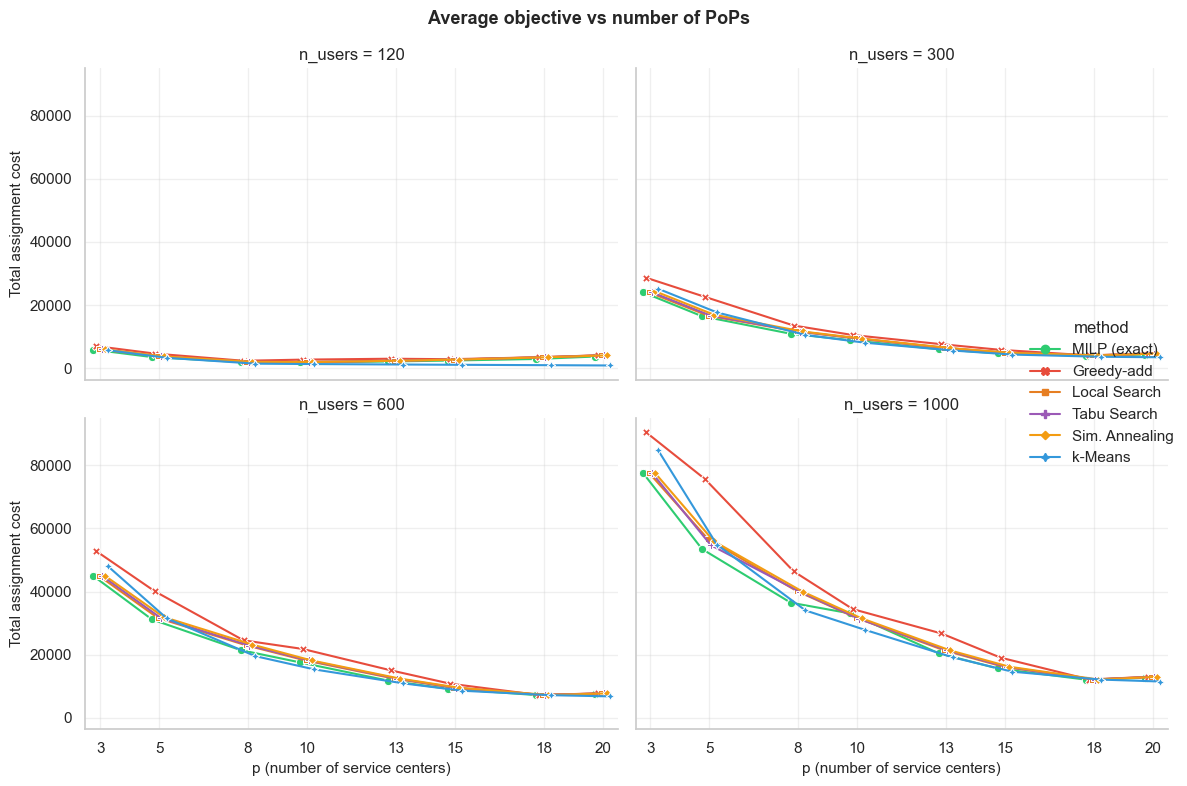

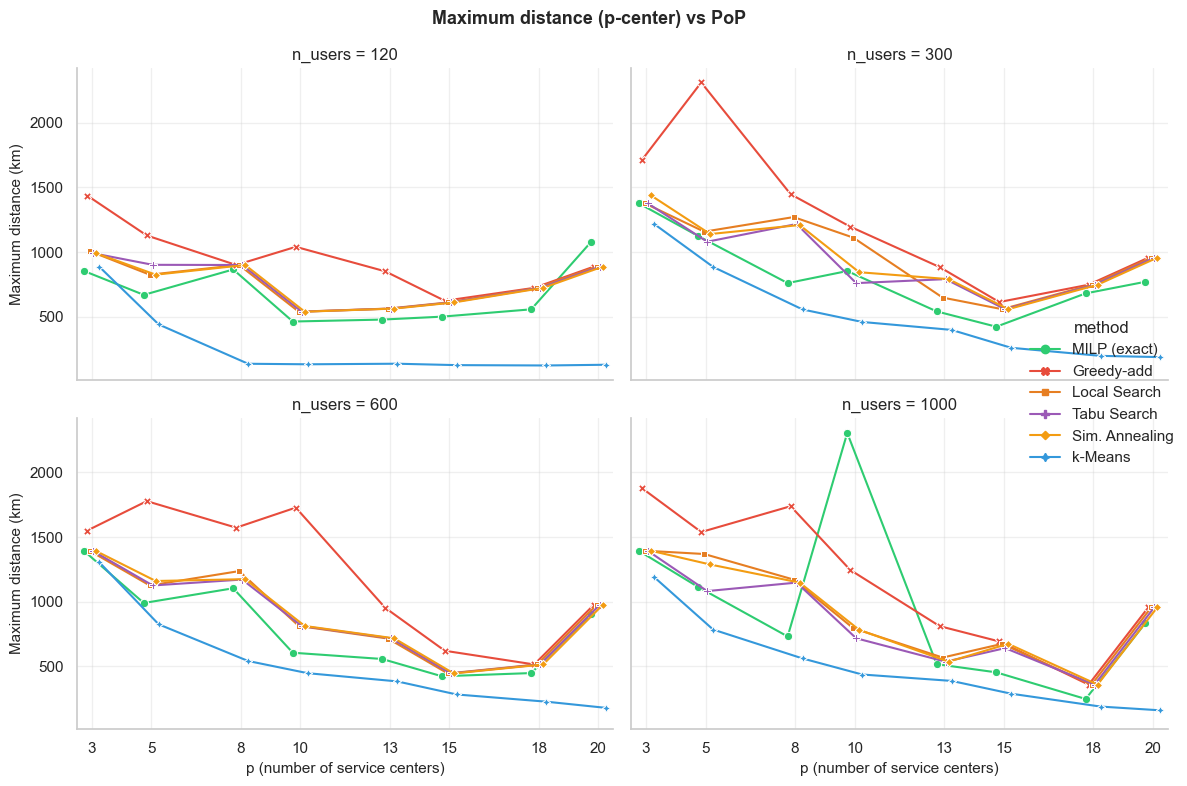

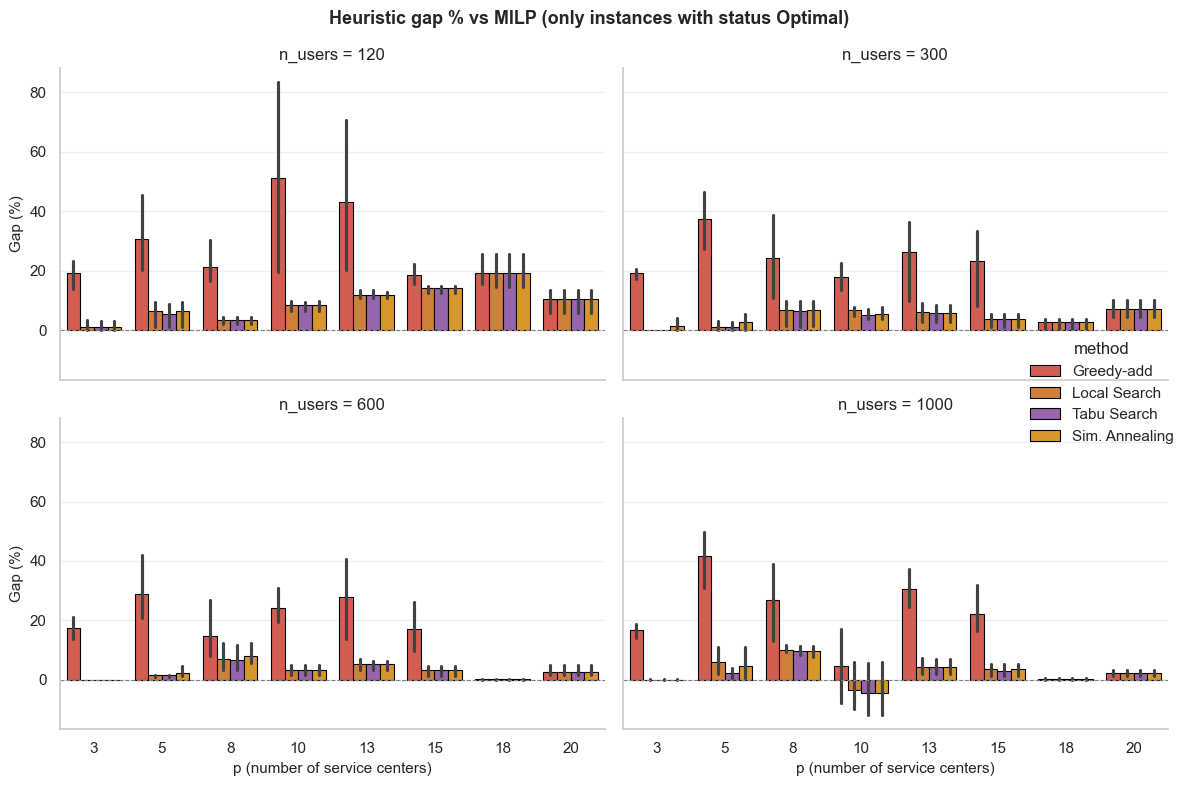

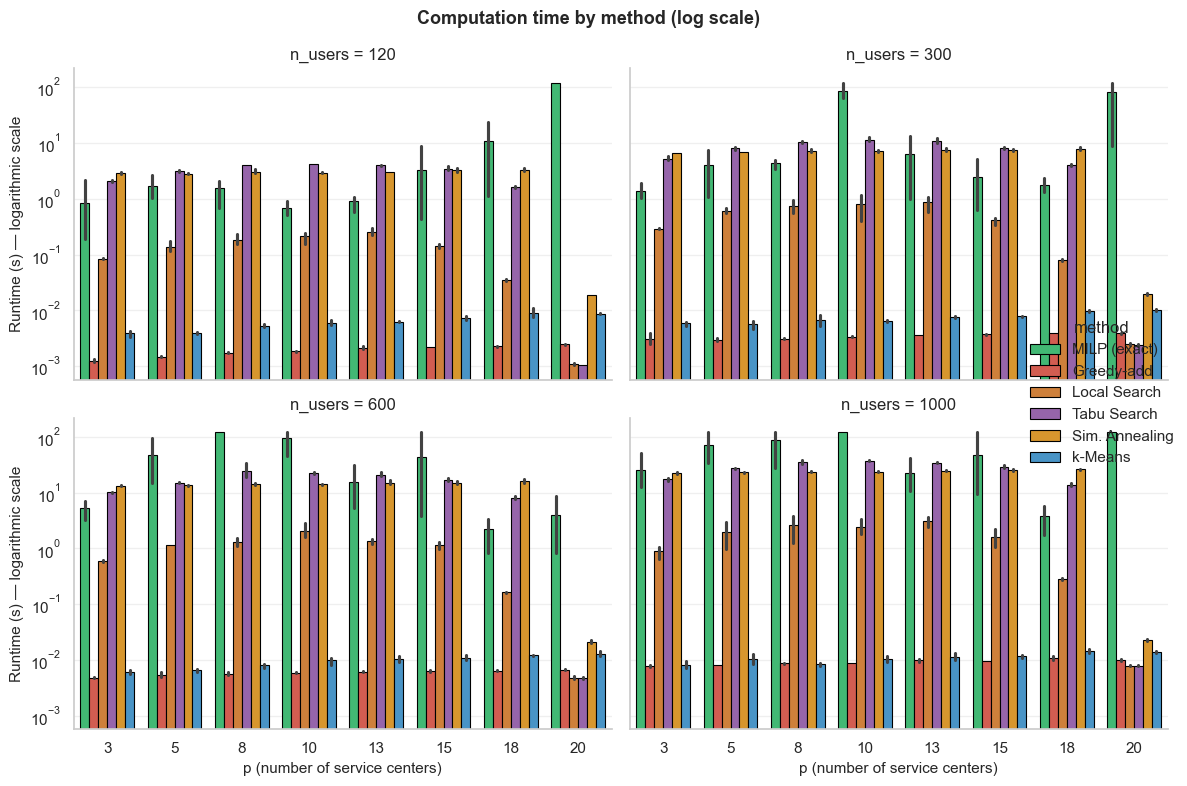

In [11]:
# ── Create output folders ──────────────────────────────────────────
results_dir = Path('results')
plots_dir = results_dir / 'plots'
results_dir.mkdir(exist_ok=True, parents=True)
plots_dir.mkdir(exist_ok=True, parents=True)

# Save CSV
results_df.to_csv(results_dir / 'results.csv', index=False)
print(f"Results saved in {results_dir / 'results.csv'}")

# ── Palette and configuration for 6 methods ───────────────────────
METHOD_STYLE = {
    'milp':          {'color': '#2ecc71', 'label': 'MILP (exact)'},
    'greedy':        {'color': '#e74c3c', 'label': 'Greedy-add'},
    'local_search':  {'color': '#e67e22', 'label': 'Local Search'},
    'tabu_search':   {'color': '#9b59b6', 'label': 'Tabu Search'},
    'sim_annealing': {'color': '#f39c12', 'label': 'Sim. Annealing'},
    'kmeans':        {'color': '#3498db', 'label': 'k-Means'},
}
palette = {m: s['color'] for m, s in METHOD_STYLE.items()}
method_labels = {m: s['label'] for m, s in METHOD_STYLE.items()}

# Small horizontal offset to separate overlapping curves (e.g. Local/Tabu/SA)
method_order = list(METHOD_STYLE.keys())
dodge = 0.10
offsets = {m: (i - (len(method_order) - 1) / 2) * dodge for i, m in enumerate(method_order)}
plot_df = results_df.copy()
plot_df['p_plot'] = (plot_df['p'] + plot_df['method'].map(offsets)).round(3)
p_ticks = sorted(plot_df['p'].unique())

# ── Facet by n_users ─────────────────────────────────────────────
n_users_vals = sorted(results_df['n_users'].unique())
col_wrap = 2 if len(n_users_vals) > 2 else None

# ── Plot 1: Average objective vs p (facet) ───────────────────────
g = sns.relplot(
    data=plot_df, x='p_plot', y='objective', hue='method',
    hue_order=method_order, style='method', style_order=method_order,
    markers=True, dashes=False, palette=palette,
    errorbar=None, kind='line', col='n_users', col_wrap=col_wrap,
    height=4, aspect=1.3,
)
for ax in g.axes.flat:
    ax.set_title(f"n_users = {ax.get_title().split(' = ')[-1]}")
    ax.set_xlabel('p (number of service centers)', fontsize=11)
    ax.set_ylabel('Total assignment cost', fontsize=11)
    ax.set_xticks(p_ticks)
    ax.set_xticklabels([str(p) for p in p_ticks])
    ax.set_xlim(min(p_ticks) - 0.5, max(p_ticks) + 0.5)
    ax.grid(True, alpha=0.3)
if g._legend is None:
    g.add_legend(title='Method')
if g._legend:
    for t in g._legend.texts:
        t.set_text(method_labels.get(t.get_text(), t.get_text()))

g.figure.suptitle('Average objective vs number of PoPs', fontweight='bold', fontsize=13)
g.figure.tight_layout()
plt.savefig(plots_dir / 'objective_vs_p_facet.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Plot 2: Average max distance vs p (facet) ────────────────────
g = sns.relplot(
    data=plot_df, x='p_plot', y='max_distance_km', hue='method',
    hue_order=method_order, style='method', style_order=method_order,
    markers=True, dashes=False, palette=palette,
    errorbar=None, kind='line', col='n_users', col_wrap=col_wrap,
    height=4, aspect=1.3,
)
for ax in g.axes.flat:
    ax.set_title(f"n_users = {ax.get_title().split(' = ')[-1]}")
    ax.set_xlabel('p (number of service centers)', fontsize=11)
    ax.set_ylabel('Maximum distance (km)', fontsize=11)
    ax.set_xticks(p_ticks)
    ax.set_xticklabels([str(p) for p in p_ticks])
    ax.set_xlim(min(p_ticks) - 0.5, max(p_ticks) + 0.5)
    ax.grid(True, alpha=0.3)
if g._legend is None:
    g.add_legend(title='Method')
if g._legend:
    for t in g._legend.texts:
        t.set_text(method_labels.get(t.get_text(), t.get_text()))

g.figure.suptitle('Maximum distance (p-center) vs PoP', fontweight='bold', fontsize=13)
g.figure.tight_layout()
plt.savefig(plots_dir / 'max_distance_vs_p_facet.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Plot 3: Heuristic gap % vs MILP (facet) ─────────────────────
milp_df = results_df[
    (results_df['method'] == 'milp') & (results_df['status'] == 'Optimal')
][['n_users', 'p', 'seed', 'objective']].rename(
    columns={'objective': 'obj_milp'}
)
heuristic_methods = ['greedy', 'local_search', 'tabu_search', 'sim_annealing']
gap_rows = []
for m in heuristic_methods:
    m_df = results_df[
        (results_df['method'] == m) & np.isfinite(results_df['objective'])
    ][['n_users', 'p', 'seed', 'objective']].rename(
        columns={'objective': 'obj_heur'}
    )
    merged = milp_df.merge(m_df, on=['n_users', 'p', 'seed'])
    merged['gap_pct'] = (merged['obj_heur'] - merged['obj_milp']) / merged['obj_milp'] * 100
    merged['method'] = m
    gap_rows.append(merged)
gap_df = pd.concat(gap_rows, ignore_index=True)

if gap_df.empty:
    print('No gap comparison available: MILP is not optimal in the considered instances.')
else:
    gap_palette = {m: palette[m] for m in heuristic_methods}
    g = sns.catplot(
        data=gap_df, x='p', y='gap_pct', hue='method',
        palette=gap_palette, kind='bar', col='n_users', col_wrap=col_wrap,
        height=4, aspect=1.3, edgecolor='black', linewidth=0.8,
    )
    for ax in g.axes.flat:
        ax.set_xlabel('p (number of service centers)', fontsize=11)
        ax.set_ylabel('Gap (%)', fontsize=11)
        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        ax.grid(True, alpha=0.3, axis='y')
    if g._legend is None:
        g.add_legend(title='Method')
    if g._legend:
        for t in g._legend.texts:
            t.set_text(method_labels.get(t.get_text(), t.get_text()))

    g.figure.suptitle('Heuristic gap % vs MILP (only instances with status Optimal)', fontweight='bold', fontsize=13)
    g.figure.tight_layout()
    plt.savefig(plots_dir / 'gap_vs_milp_facet.png', dpi=200, bbox_inches='tight')
    plt.show()

# ── Plot 4: Runtime comparison (log scale, facet) ───────────────
g = sns.catplot(
    data=results_df, x='p', y='runtime', hue='method',
    palette=palette, kind='bar', col='n_users', col_wrap=col_wrap,
    height=4, aspect=1.3, edgecolor='black', linewidth=0.8,
)
for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel('p (number of service centers)', fontsize=11)
    ax.set_ylabel('Runtime (s) — logarithmic scale', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
if g._legend is None:
    g.add_legend(title='Method')
if g._legend:
    for t in g._legend.texts:
        t.set_text(method_labels.get(t.get_text(), t.get_text()))

g.figure.suptitle('Computation time by method (log scale)', fontweight='bold', fontsize=13)
g.figure.tight_layout()
plt.savefig(plots_dir / 'runtime_facet.png', dpi=200, bbox_inches='tight')
plt.show()


### Summary tables of numerical results for each *p* value

For each value of *p*, a table reports mean and 95% confidence interval (Student's *t* distribution), together with solver status and a MILP optimality flag. The **best result** for each metric is highlighted in green.


In [12]:
# ── Numerical tables for each p value (95% CI) ───────────────────
from scipy import stats as _stats

_metrics = ['objective', 'max_distance_km', 'runtime']
_metric_labels = {
    'objective': 'Assignment cost',
    'max_distance_km': 'Dist. max (km)',
    'runtime': 'Runtime (s)',
}

for p_val in sorted(results_df['p'].unique()):
    _table_rows = []
    for m in METHOD_STYLE:
        sub = results_df[(results_df['method'] == m) & (results_df['p'] == p_val)]
        status_values = sorted(sub['status'].dropna().astype(str).unique())
        status_text = ', '.join(status_values) if status_values else 'n/a'
        if m == 'milp':
            n_opt = int((sub['status'] == 'Optimal').sum())
            n_tot = int(len(sub))
            if n_tot == 0:
                milp_opt_flag = 'n/a'
            elif n_opt == n_tot:
                milp_opt_flag = 'Yes'
            elif n_opt > 0:
                milp_opt_flag = 'Partial'
            else:
                milp_opt_flag = 'No'
        else:
            milp_opt_flag = '—'
        row = {
            'Method': METHOD_STYLE[m]['label'],
            'Status': status_text,
            'MILP optimal': milp_opt_flag,
        }
        for metric in _metrics:
            vals = sub[metric].dropna()
            n = len(vals)
            mu = vals.mean()
            if n > 1:
                sem = vals.std(ddof=1) / np.sqrt(n)
                t_crit = _stats.t.ppf(0.975, df=n - 1)
                ci = t_crit * sem
            else:
                ci = 0.0
            row[_metric_labels[metric]] = mu
            row[f'±95% CI ({_metric_labels[metric]})'] = ci
        _table_rows.append(row)

    df_p = pd.DataFrame(_table_rows)

    # Highlight best and second-best for each metric — colors for dark theme
    def _highlight_best(s):
        """Highlights minimum and second value by column."""
        finite_vals = [v for v in s if np.isfinite(v)]
        if not finite_vals:
            return [''] * len(s)
        vals = sorted(set(finite_vals))
        best = vals[0]
        second = vals[1] if len(vals) > 1 else None
        styles = []
        for v in s:
            if not np.isfinite(v):
                styles.append('')
            elif np.isclose(v, best):
                styles.append('background-color: #1a5e2a !important; color: #8fffb0 !important; font-weight: bold')
            elif second is not None and np.isclose(v, second):
                styles.append('background-color: #7a6a00 !important; color: #fff3b0 !important; font-weight: bold')
            else:
                styles.append('')
        return styles
    value_cols = list(_metric_labels.values())
    styled = (df_p.style
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'),
                                                     ('margin-bottom', '8px'), ('color', '#e0e0e0')]},
                  {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#e0e0e0'),
                                                ('font-size', '11px')]},
                  {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center'),
                                                ('color', '#d0d0d0'), ('background-color', '#1e1e1e')]},
              ])
              .apply(_highlight_best, subset=value_cols)
              .format({
                  'Assignment cost': '{:.1f}',
                  '±95% CI (Assignment cost)': '±{:.1f}',
                  'Dist. max (km)': '{:.1f}',
                  '±95% CI (Dist. max (km))': '±{:.1f}',
                  'Runtime (s)': '{:.4f}',
                  '±95% CI (Runtime (s))': '±{:.4f}',
              })
              .set_caption(f'Results for p = {p_val} — mean ± 95% CI')
              .hide(axis='index'))
    display(styled)
    print()  # spacer between tables


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,38151.7,±17711.3,1254.5,±153.9,8.2178,±8.9545
Greedy-add,greedy,—,44777.5,±20592.9,1644.4,±285.3,0.0042,±0.0016
Local Search,local_search,—,38183.6,±17708.2,1292.7,±135.0,0.4648,±0.2127
Tabu Search,tabu_search,—,38180.3,±17710.8,1288.9,±134.7,8.7093,±3.8196
Sim. Annealing,simulated_annealing,—,38266.8,±17682.6,1304.4,±143.4,11.4181,±5.0200
k-Means,kmeans,—,41009.5,±19604.4,1152.8,±117.9,0.0060,±0.0011


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,26150.2,±12335.1,974.3,±159.8,31.3942,±25.9682
Greedy-add,greedy,—,35720.7,±17452.2,1689.2,±337.9,0.0045,±0.0017
Local Search,local_search,—,27162.8,±13102.7,1119.5,±167.2,0.9580,±0.5163
Tabu Search,tabu_search,—,26656.5,±12606.4,1047.5,±109.9,13.3719,±6.0164
Sim. Annealing,simulated_annealing,—,27129.9,±12929.7,1103.3,±170.3,11.6660,±5.1951
k-Means,kmeans,—,26842.0,±12669.1,734.0,±121.3,0.0067,±0.0017


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,17678.6,±8553.8,865.4,±217.5,53.9176,±37.4794
Greedy-add,greedy,—,21688.0,±10947.9,1414.7,±270.7,0.0048,±0.0018
Local Search,local_search,—,19182.4,±9450.9,1144.8,±241.8,1.2000,±0.6935
Tabu Search,tabu_search,—,19109.6,±9396.3,1109.2,±209.4,18.6226,±8.5491
Sim. Annealing,simulated_annealing,—,19183.7,±9407.3,1107.9,±238.2,12.0068,±5.1681
k-Means,kmeans,—,16360.5,±7989.3,449.1,±123.7,0.0071,±0.0010


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,15325.7,±7797.1,1056.9,±499.9,75.1547,±33.0320
Greedy-add,greedy,—,17350.5,±7965.9,1302.7,±259.6,0.0050,±0.0018
Local Search,local_search,—,15321.8,±7360.9,814.9,±199.3,1.3755,±0.6949
Tabu Search,tabu_search,—,15203.6,±7288.8,707.4,±102.8,18.7220,±8.2250
Sim. Annealing,simulated_annealing,—,15230.9,±7308.5,744.7,±106.1,12.0760,±5.2394
k-Means,kmeans,—,13136.6,±6553.1,369.3,±92.3,0.0081,±0.0015


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,10078.0,±4589.2,523.6,±36.7,11.1979,±8.1458
Greedy-add,greedy,—,13060.5,±5978.6,875.0,±117.5,0.0054,±0.0019
Local Search,local_search,—,10613.0,±4759.4,623.7,±68.9,1.3988,±0.7282
Tabu Search,tabu_search,—,10599.0,±4754.0,651.9,±127.8,17.4664,±7.6000
Sim. Annealing,simulated_annealing,—,10599.0,±4754.0,651.9,±127.8,12.6288,±5.5165
k-Means,kmeans,—,9173.6,±4446.1,326.9,±74.8,0.0089,±0.0015


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,7971.2,±3363.4,450.4,±66.8,23.8167,±28.6559
Greedy-add,greedy,—,9606.5,±4097.4,637.9,±55.1,0.0054,±0.0018
Local Search,local_search,—,8307.8,±3426.9,572.3,±123.9,0.8364,±0.4238
Tabu Search,tabu_search,—,8291.0,±3410.2,564.0,±126.3,14.4122,±6.4846
Sim. Annealing,simulated_annealing,—,8307.8,±3426.9,572.3,±123.9,12.7747,±5.5966
k-Means,kmeans,—,7120.4,±3367.3,239.5,±44.8,0.0094,±0.0013


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,6516.7,±2372.0,483.7,±204.8,4.7044,±3.9977
Greedy-add,greedy,—,6696.9,±2282.6,586.3,±216.8,0.0058,±0.0021
Local Search,local_search,—,6696.9,±2282.6,586.3,±216.8,0.1394,±0.0623
Tabu Search,tabu_search,—,6696.9,±2282.6,586.3,±216.8,6.9258,±3.1117
Sim. Annealing,simulated_annealing,—,6696.9,±2282.6,586.3,±216.8,13.3386,±5.7564
k-Means,kmeans,—,5938.2,±2776.7,184.5,±30.4,0.0113,±0.0015


Method,Status,MILP optimal,Assignment cost,±95% CI (Assignment cost),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (exact),Optimal,Yes,7039.7,±2365.7,895.8,±204.8,82.1478,±36.1506
Greedy-add,greedy,—,7337.7,±2352.0,944.0,±137.4,0.0057,±0.0019
Local Search,local_search,—,7337.7,±2352.0,944.0,±137.4,0.0041,±0.0017
Tabu Search,tabu_search,—,7337.7,±2352.0,944.0,±137.4,0.0040,±0.0017
Sim. Annealing,simulated_annealing,—,7337.7,±2352.0,944.0,±137.4,0.0204,±0.0011
k-Means,kmeans,—,5631.9,±2641.9,164.3,±20.2,0.0114,±0.0014


In [13]:
# ── Overall ranking by average objective ─────────────────────────
valid_results = results_df[np.isfinite(results_df['objective'])].copy()

all_mean = valid_results.groupby('method').agg(
    obj_mean=('objective', 'mean'),
    dist_mean=('max_distance_km', 'mean'),
    time_mean=('runtime', 'mean'),
)

# MILP reference per instance (n_users, p, seed)
milp_ref = valid_results[valid_results['method'] == 'milp'][['n_users', 'p', 'seed', 'objective']].rename(
    columns={'objective': 'milp_obj'}
)
cmp = valid_results.merge(milp_ref, on=['n_users', 'p', 'seed'], how='left')
cmp['gap_vs_milp_pct'] = (cmp['objective'] - cmp['milp_obj']) / cmp['milp_obj'] * 100

# Average gap per instance (metric used in ranking)
gap_mean_instance = cmp.groupby('method')['gap_vs_milp_pct'].mean()

ranking = all_mean['obj_mean'].sort_values()
_rank_rows = []
for rank, m in enumerate(ranking.index, 1):
    _rank_rows.append({
        '#': rank,
        'Method': METHOD_STYLE[m]['label'],
        'Avg. obj.': float(all_mean.loc[m, 'obj_mean']),
        'Avg. time (s)': float(all_mean.loc[m, 'time_mean']),
        'Avg. gap vs MILP (%)': (np.nan if m == 'milp' else float(gap_mean_instance.get(m, np.nan))),
    })

_df_rank = pd.DataFrame(_rank_rows)

styled = (_df_rank.style
          .hide(axis='index')
          .set_caption('Overall ranking (all p, n_users, and seeds)')
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'),
                                                 ('margin-bottom', '8px'), ('color', '#e0e0e0')]},
              {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#e0e0e0')]},
              {'selector': 'td', 'props': [('text-align', 'center'), ('color', '#d0d0d0'),
                                            ('background-color', '#1e1e1e')]},
          ])
          .format({
              'Avg. obj.': '{:.1f}',
              'Avg. time (s)': '{:.3f}',
              'Avg. gap vs MILP (%)': lambda x: '—' if pd.isna(x) else f'{x:.2f}%',
          }))

display(styled)


#,Method,Avg. obj.,Avg. time (s),Avg. gap vs MILP (%)
1,k-Means,15651.6,0.009,-13.18%
2,MILP (exact),16114.0,36.319,—
3,Tabu Search,16509.3,12.279,4.59%
4,Sim. Annealing,16594.1,10.741,4.90%
5,Local Search,16600.7,0.797,4.89%
6,Greedy-add,19529.8,0.005,20.34%


### Remarks on results

The ranking is built using the **average per-instance gap** with respect to MILP, i.e.:

$$\text{gap}_i(\%) = \frac{z_{\text{method},i} - z_{\text{MILP},i}}{z_{\text{MILP},i}}\cdot 100$$

with final average over all instances $(n\_users, p, seed)$.

This choice is consistent with experimental analysis because it avoids mixing method comparison with the different scale of objective values as `n_users` varies.

Key interpretation points:

- `MILP` is the exact reference for the **capacitated** p-median model.
- `Greedy` is very fast but usually farther in solution quality.
- `Local Search`, `Tabu Search`, and `Simulated Annealing` reduce the gap with respect to Greedy, with different time/quality trade-offs.
- `k-Means` should be interpreted as a **qualitative baseline**: it uses continuous centroids and does not enforce the same constraints as the capacitated discrete model, so values are not directly comparable with MILP.

Methodological note: since capacities are generated as a function of `p`, comparison across different `p` values changes not only the number of open centers but also the candidates' capacity profile.


## 9 • Geospatial visualization of clustering

For a representative instance (`seed=0`, `p=5`), results of all six solution methods are visualized on an **interactive map** (Folium). Each user is connected to its center with a color identifying the cluster, making the spatial structure of the solution and differences across approaches immediately clear.

- **MILP** — exact solution (CBC solver);
- **Greedy-add** — constructive heuristic;
- **Local Search** — improvement heuristic (Teitz & Bart);
- **Tabu Search** — metaheuristic with tabu list;
- **Simulated Annealing** — metaheuristic with probabilistic acceptance;
- **k-Means** — baseline with *imaginary* centroids (not constrained to PoP candidates).


In [14]:
# ── Geospatial maps for ALL methods — seed=0, p=5 ───────────────

# Cluster colors
CLUSTER_COLORS = [
    '#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12',
    '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4',
]

def make_cluster_map(coords, assign, open_hubs, title='Clustering',
                     hub_coords=None, hub_labels=None, width='100%', height='680px'):
    """Creates a Folium map with colored clusters and assignment lines."""
    center_lat = float(np.mean(coords[:, 0]))
    center_lon = float(np.mean(coords[:, 1]))
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=5,
        tiles='CartoDB positron',
        width=width,
        height=height,
        control_scale=True,
        prefer_canvas=True,
    )

    _hub_coords = hub_coords if hub_coords is not None else pop_coords
    _hub_labels = hub_labels

    hub_color = {h: CLUSTER_COLORS[idx % len(CLUSTER_COLORS)] for idx, h in enumerate(open_hubs)}

    for h in open_hubs:
        label = _hub_labels[h] if _hub_labels is not None else POP_CANDIDATES[h]['name']
        folium.Marker(
            location=[float(_hub_coords[h, 0]), float(_hub_coords[h, 1])],
            popup=label,
            icon=folium.Icon(color='white', icon_color=hub_color[h], icon='server', prefix='fa'),
        ).add_to(m)

    for i in range(len(coords)):
        hub = int(assign[i])
        color = hub_color.get(hub, 'gray')
        folium.CircleMarker(
            location=[float(coords[i, 0]), float(coords[i, 1])],
            radius=4, color=color, fill=True, fill_opacity=0.7, weight=1,
        ).add_to(m)
        folium.PolyLine(
            locations=[
                [float(coords[i, 0]), float(coords[i, 1])],
                [float(_hub_coords[hub, 0]), float(_hub_coords[hub, 1])],
            ],
            color=color, weight=1.5, opacity=0.4,
        ).add_to(m)

    # Frame all points (customers + hubs), also useful for webpdf export.
    all_points = [[float(lat), float(lon)] for lat, lon in coords]
    all_points.extend([[float(_hub_coords[h, 0]), float(_hub_coords[h, 1])] for h in open_hubs])
    if all_points:
        m.fit_bounds(all_points, padding=(20, 20))

    title_html = f'<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);z-index:9999;background:white;padding:8px 16px;border-radius:8px;box-shadow:0 2px 6px rgba(0,0,0,.3);font:bold 14px sans-serif;">{title}</div>'
    m.get_root().html.add_child(folium.Element(title_html))

    # Force Leaflet recalculation during headless PDF printing.
    map_name = m.get_name()
    js_fix = folium.Element(f"""
    <script>
    setTimeout(function() {{
      if (window.{map_name}) {{
        window.{map_name}.invalidateSize();
      }}
    }}, 350);
    </script>
    """)
    m.get_root().html.add_child(js_fix)

    return m


# ── Prepare instance seed=0, p=5 ─────────────────────────────────
_seed, _p = 0, 5
_coords, _demands = sample_users(120, _seed)
_dist_km = haversine_matrix(_coords, pop_coords)
_eff = effective_cost_per_km()
_dist_cost = _dist_km * _eff
_caps = build_capacities(_demands, _p, _seed)

# ── MILP solution ──
_milp = solve_pmedian_pulp(_dist_cost, _demands, _p, capacities=_caps)
map_milp = make_cluster_map(_coords, _milp['assign'], _milp['open'],
                            title='Clustering MILP — p=5, seed=0')

# ── Greedy solution ──
_greedy = greedy_solution(_dist_cost, _demands, _p, capacities=_caps)
map_greedy = make_cluster_map(_coords, _greedy['assign'], _greedy['open'],
                              title='Clustering Greedy — p=5, seed=0')

# ── Local Search solution ──
_ls = local_search_swap(_dist_cost, _demands, _p, capacities=_caps,
                        initial_open=list(_greedy['open']))
map_ls = make_cluster_map(_coords, _ls['assign'], _ls['open'],
                          title='Clustering Local Search — p=5, seed=0')

# ── Tabu Search solution ──
_ts = tabu_search(_dist_cost, _demands, _p, capacities=_caps,
                  initial_open=list(_greedy['open']))
map_ts = make_cluster_map(_coords, _ts['assign'], _ts['open'],
                          title='Clustering Tabu Search — p=5, seed=0')

# ── Simulated Annealing solution ──
_sa = simulated_annealing(_dist_cost, _demands, _p, capacities=_caps,
                          initial_open=list(_greedy['open']), seed=_seed)
map_sa = make_cluster_map(_coords, _sa['assign'], _sa['open'],
                          title='Clustering Sim. Annealing — p=5, seed=0')

# ── k-Means solution (imaginary centroids) ──
_kmeans = kmeans_baseline(_coords, _demands, _p, _seed)
_km_centroids = _kmeans['centroids']
_km_labels = _kmeans['assign']
_km_hub_labels = {i: f'Centroid {i+1}' for i in range(_p)}
map_kmeans = make_cluster_map(
    _coords, _km_labels, list(range(_p)),
    title='Clustering k-Means — p=5, seed=0',
    hub_coords=_km_centroids,
    hub_labels=_km_hub_labels,
)

print("▶ MILP map (exact solution):")
map_milp



▶ MILP map (exact solution):


In [15]:
print("▶ Greedy-add map:")
map_greedy

▶ Greedy-add map:


In [16]:
print("▶ k-Means map (imaginary centroids):")
map_kmeans

▶ k-Means map (imaginary centroids):


## 10 • Distance heatmap

The **heatmap** shows the distance matrix (km) between all demand nodes and candidate service centers (PoPs), highlighting high/low-distance areas. It does not represent a specific solution, but the problem structure: it helps identify which centers are naturally closer to specific user groups.


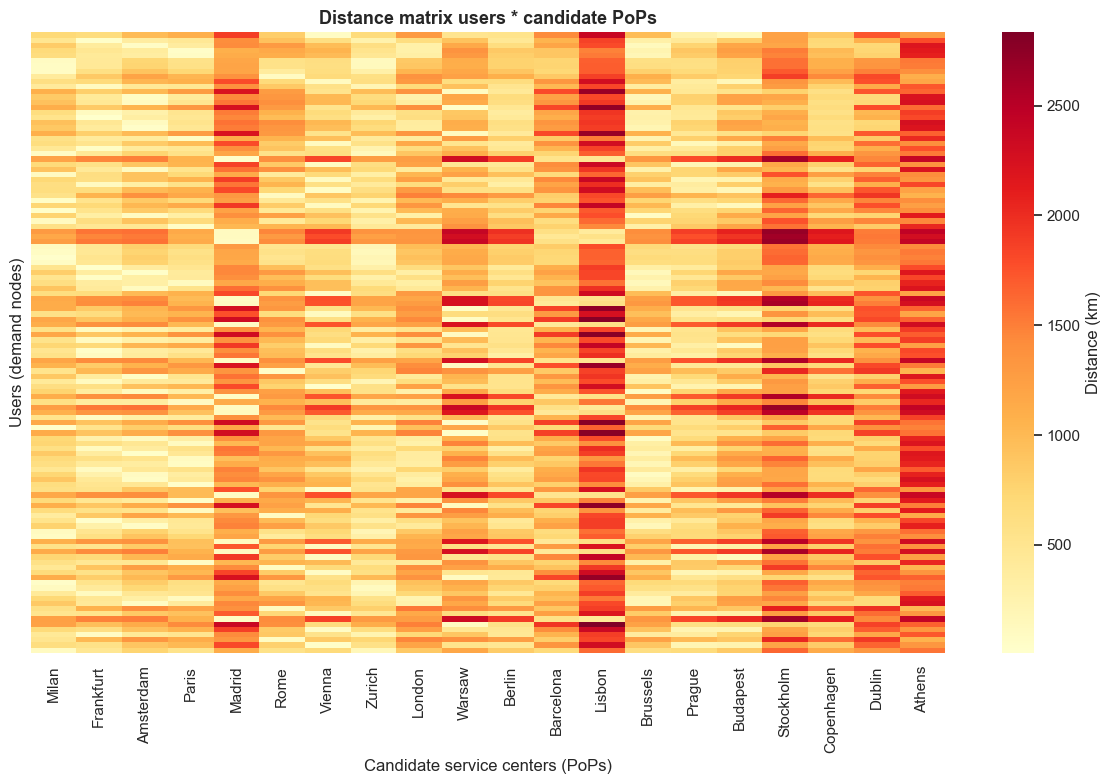

In [17]:
# ── Distance heatmap users * candidate PoPs ──────────────────────
pop_names = [c['name'] for c in POP_CANDIDATES]
heatmap_data = pd.DataFrame(_dist_km, columns=pop_names)
heatmap_data.index.name = 'User'

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Distance (km)'},
    xticklabels=True,
    yticklabels=False,
)
ax.set_title('Distance matrix users * candidate PoPs', fontweight='bold', fontsize=13)
ax.set_xlabel('Candidate service centers (PoPs)')
ax.set_ylabel('Users (demand nodes)')
plt.tight_layout()
plt.savefig(plots_dir / 'heatmap_distanze.png', dpi=200, bbox_inches='tight')
plt.show()

## 11 • Deep dive: solving with IBM ILOG CPLEX

As an additional analysis, the same capacitated p-median problem is solved using **IBM ILOG CPLEX Optimization Studio** through the Python `docplex` library.

CPLEX is a high-performance commercial solver for mathematical programming problems (LP, MIP, QP). Like CBC, it uses **Branch-and-Cut** techniques (branching + cutting planes) to close the optimality gap.

Algorithmically, at each node of the decision tree this cycle occurs:

1. solve the linear relaxation;
2. possibly generate valid cuts to improve the bound;
3. if needed, branch on fractional variables;
4. prune nodes dominated by bounds or infeasible nodes.

The comparison is carried out **between CPLEX, CBC, and the best heuristic** on the same reduced sub-instance, to evaluate:
- **agreement** between the two exact solvers (CPLEX and CBC);
- **time performance** of CPLEX versus CBC (speed-up);
- the best heuristic **gap** with respect to the CPLEX solution.

The Community Edition imposes a limit of **1000 variables** and **1000 constraints**. With the current 20 candidates ($m = 20$), the maximum is $n \le 46$ users (940 variables, 987 constraints).

Status note: `cplex_optimal` indicates certified optimality; `cplex_feasible` indicates a feasible solution found without optimality certification (typically due to early stop or resource limits).


In [18]:
# ── MILP solve with CPLEX (docplex) ─────────────────────────────
import time as _time
from docplex.mp.model import Model as CplexModel

_test = CplexModel(name="_test")
_test.binary_var(name="_t")
_test.minimize(_test.sum([]))
_test_sol = _test.solve(log_output=False)
if _test_sol is None:
    raise RuntimeError("initial CPLEX test without solution")


def solve_pmedian_cplex(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
) -> dict:
    """Solves the Capacitated p-Median with CPLEX via docplex.

    Formulation identical to the one used with PuLP:
        min  Σ_i Σ_j  d_i * c_ij * x_ij
        s.t. Σ_j y_j = p
             Σ_j x_ij = 1               ∀ i  (unique assignment)
             x_ij ≤ y_j                  ∀ i,j
             Σ_i d_i * x_ij ≤ Q_j * y_j ∀ j  (capacity)
             x_ij ∈ {0,1}, y_j ∈ {0,1}
    """
    n_users, n_candidates = dist_cost.shape
    mdl = CplexModel(name="capacitated_p_median")

    # ── Variables ──
    x = {(i, j): mdl.binary_var(name=f"x_{i}_{j}")
         for i in range(n_users) for j in range(n_candidates)}
    y = {j: mdl.binary_var(name=f"y_{j}") for j in range(n_candidates)}

    # ── Objective function ──
    mdl.minimize(
        mdl.sum(demands[i] * dist_cost[i, j] * x[i, j]
                for i in range(n_users) for j in range(n_candidates))
    )

    # ── Constraints ──
    mdl.add_constraint(mdl.sum(y[j] for j in range(n_candidates)) == p,
                       ctname="num_hubs")
    for i in range(n_users):
        mdl.add_constraint(
            mdl.sum(x[i, j] for j in range(n_candidates)) == 1,
            ctname=f"assign_{i}")
    for i in range(n_users):
        for j in range(n_candidates):
            mdl.add_constraint(x[i, j] <= y[j], ctname=f"link_{i}_{j}")
    for j in range(n_candidates):
        mdl.add_constraint(
            mdl.sum(demands[i] * x[i, j] for i in range(n_users))
            <= capacities[j] * y[j], ctname=f"cap_{j}")

    # ── Solve ──
    t0 = _time.perf_counter()
    sol = mdl.solve(log_output=False)
    runtime = _time.perf_counter() - t0

    if sol is None:
        raise RuntimeError(f"solve_pmedian_cplex: no solution, details={mdl.solve_details}")

    open_hubs = [j for j in range(n_candidates) if y[j].solution_value > 0.5]
    assign = [0] * n_users
    for i in range(n_users):
        for j in open_hubs:
            if x[i, j].solution_value > 0.5:
                assign[i] = j
                break

    return {
        "status": "cplex_optimal" if sol.solve_details.status == "optimal" else "cplex_feasible",
        "objective": sol.objective_value,
        "open": open_hubs,
        "assign": assign,
        "runtime": runtime,
        "feasible": True,
        "gap": sol.solve_details.mip_relative_gap if hasattr(sol.solve_details, 'mip_relative_gap') else None,
        "solve_details": str(sol.solve_details),
    }


# ── Subsampling for Community Edition limits ────────────────────
# vars = n * m + m,  constr = 1 + n + n * m + m
# CE limits: 1000 vars, 1000 constraints  ->  n_max = floor((1000 - 1 - m) / (m + 1))
_n_cand = len(POP_CANDIDATES)
_n_cplex = min(CONFIG['n_users'][0], (1000 - 1 - _n_cand) // (_n_cand + 1))
_n_vars = _n_cplex * _n_cand + _n_cand
_n_constr = 1 + _n_cplex + _n_cplex * _n_cand + _n_cand

print(f"Sub-instance for CPLEX (Community Edition):")
print(f"  • Users:             {_n_cplex} / {CONFIG['n_users'][0]}")
print(f"  • Binary variables:  {_n_vars}  "
      f"({_n_cplex}*{_n_cand} x_ij + {_n_cand} y_j)")
print(f"  • Constraints:            {_n_constr}")
print()

# ── Run CPLEX vs CBC comparison ─────────────────────────────────
print("=" * 65)
print("  COMPARISON  CPLEX  vs  CBC (PuLP)  —  capacitated p-median")
print("=" * 65)
print(f"  Sub-instance: {_n_cplex} users, {_n_cand} candidates")
print()

_seed = CONFIG['seeds'][0]
_coords_full, _demands_full = sample_users(CONFIG['n_users'][0], _seed)

# deterministic subsampling (first _n_cplex users)
_coords = _coords_full[:_n_cplex]
_demands = _demands_full[:_n_cplex]
_dist_km = haversine_matrix(_coords, pop_coords)
_dist_cost = _dist_km * effective_cost_per_km()

cplex_results = {}
cbc_sub_results = {}
for p_val in CONFIG['p_values']:
    _caps = build_capacities(_demands, p_val, _seed)
    print(f"▸ p = {p_val}", flush=True)

    # ── CPLEX on the sub-instance ──
    res_cpx = solve_pmedian_cplex(_dist_cost, _demands, p_val, _caps)
    cplex_results[p_val] = res_cpx
    print(f"  CPLEX:  obj = {res_cpx['objective']:.1f}  "
          f"t = {res_cpx['runtime']:.2f}s  ({res_cpx['status']})")

    # ── CBC (PuLP) on the same sub-instance ──
    res_cbc = solve_pmedian_pulp(_dist_cost, _demands, p_val, _caps)
    cbc_sub_results[p_val] = res_cbc
    print(f"  CBC:    obj = {res_cbc['objective']:.1f}  "
          f"t = {res_cbc['runtime']:.2f}s")

# ── Comparison table ──
rows_cmp = []
for p_val in CONFIG['p_values']:
    cpx = cplex_results[p_val]
    cbc = cbc_sub_results[p_val]
    cbc_obj = cbc["objective"]
    if cpx["runtime"] <= 0:
        raise RuntimeError("Non-positive CPLEX runtime: cannot compute speed-up")
    rows_cmp.append({
        "p": p_val,
        "Obj CBC": cbc_obj,
        "Obj CPLEX": cpx["objective"],
        "Gap Obj (%)": abs(cpx["objective"] - cbc_obj) / cbc_obj * 100
                       if cbc_obj else 0,
        "T. CBC (s)": cbc["runtime"],
        "T. CPLEX (s)": cpx["runtime"],
        "Speed-up": cbc["runtime"] / cpx["runtime"],
    })

if rows_cmp:
    df_cmp = pd.DataFrame(rows_cmp).set_index("p")
    speedup_series = df_cmp["Speed-up"]
    speedup_min = 0.5
    speedup_cap = float(speedup_series.quantile(0.75))
    speedup_cap = max(min(speedup_cap, 6.0), 2.0)
    speedup_gmap = speedup_series.clip(lower=speedup_min, upper=speedup_cap)

    display(df_cmp.style
            .format({"Obj CBC": "{:.1f}", "Obj CPLEX": "{:.1f}",
                     "Gap Obj (%)": "{:.2f}", "T. CBC (s)": "{:.3f}",
                     "T. CPLEX (s)": "{:.3f}", "Speed-up": "{:.1f}×"})
            .background_gradient(subset=["Speed-up"], cmap="Greens",
                                 vmin=speedup_min, vmax=speedup_cap,
                                 gmap=speedup_gmap,
                                 low=0.2, high=0.95)
            .set_caption(f"CPLEX vs CBC comparison — sub-instance {_n_cplex} users")
            .set_table_styles([
                {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'),
                                                   ('margin-bottom', '8px'), ('color', '#e0e0e0')]},
                {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#e0e0e0')]},
                {'selector': 'td', 'props': [('text-align', 'center'), ('color', '#d0d0d0')]},
            ]))

Sub-instance for CPLEX (Community Edition):
  • Users:             46 / 120
  • Binary variables:  940  (46*20 x_ij + 20 y_j)
  • Constraints:            987

  COMPARISON  CPLEX  vs  CBC (PuLP)  —  capacitated p-median
  Sub-instance: 46 users, 20 candidates

▸ p = 3
  CPLEX:  obj = 1990.5  t = 0.24s  (cplex_feasible)
  CBC:    obj = 1990.5  t = 0.76s
▸ p = 5
  CPLEX:  obj = 1384.9  t = 0.16s  (cplex_feasible)
  CBC:    obj = 1384.9  t = 0.42s
▸ p = 8
  CPLEX:  obj = 928.8  t = 0.41s  (cplex_feasible)
  CBC:    obj = 928.8  t = 1.82s
▸ p = 10
  CPLEX:  obj = 792.2  t = 0.14s  (cplex_feasible)
  CBC:    obj = 792.2  t = 0.28s
▸ p = 13
  CPLEX:  obj = 1039.9  t = 0.17s  (cplex_feasible)
  CBC:    obj = 1039.9  t = 0.43s
▸ p = 15
  CPLEX:  obj = 1219.8  t = 0.16s  (cplex_feasible)
  CBC:    obj = 1219.8  t = 0.74s
▸ p = 18
  CPLEX:  obj = 1491.4  t = 0.27s  (cplex_feasible)
  CBC:    obj = 1491.4  t = 1.61s
▸ p = 20
  CPLEX:  obj = 1722.7  t = 0.25s  (cplex_feasible)
  CBC:    obj = 1722

,Obj CBC,Obj CPLEX,Gap Obj (%),T. CBC (s),T. CPLEX (s),Speed-up
p,,,,,,
3,1990.5,1990.5,0.00,0.761,0.241,3.2×
5,1384.9,1384.9,0.00,0.416,0.161,2.6×
8,928.8,928.8,0.00,1.817,0.409,4.4×
10,792.2,792.2,0.00,0.276,0.144,1.9×
13,1039.9,1039.9,0.00,0.431,0.169,2.5×
15,1219.8,1219.8,0.00,0.738,0.158,4.7×
18,1491.4,1491.4,0.00,1.610,0.271,5.9×
20,1722.7,1722.7,0.00,62.739,0.246,254.7×
